In [3]:
import pandas as pd
import re
import string


import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download resources (run once)
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('omw-1.4')

df = pd.read_csv("B:/Semester7/Data Mining/Project/dataset_crawler-google-places_new.csv")


In [4]:
stars = pd.read_csv("B:/Semester7/Data Mining/Project/dataset_crawler-google-places_stars.csv")

In [5]:
df = df.merge(stars, on='title', how='left')
df.head()

,title,stars,text,publishedAtDate,likesCount,name,reviewerNumberOfReviews,isLocalGuide,responseFromOwnerDate,responseFromOwnerText,...,totalScore,reviewsCount,street,city,state,countryCode,website,phone,categoryName,url
0,US Fried Chicken,1,Здесь очередь не смотреть груба обращается и а...,2025-12-24T15:27:15.230Z,0,NaN,0,False,NaN,NaN,...,4.3,132,129 Dwight St,Brooklyn,New York,US,https://www.usfriedchickenmenu.com/?utm_source...,(718) 643-4662,Chicken restaurant,https://www.google.com/maps/search/?api=1&quer...
1,US Fried Chicken,5,NaN,2025-10-08T18:05:14.156Z,0,NaN,5,False,NaN,NaN,...,4.3,132,129 Dwight St,Brooklyn,New York,US,https://www.usfriedchickenmenu.com/?utm_source...,(718) 643-4662,Chicken restaurant,https://www.google.com/maps/search/?api=1&quer...
2,US Fried Chicken,5,NaN,2025-10-08T01:07:02.726Z,0,NaN,24,True,NaN,NaN,...,4.3,132,129 Dwight St,Brooklyn,New York,US,https://www.usfriedchickenmenu.com/?utm_source...,(718) 643-4662,Chicken restaurant,https://www.google.com/maps/search/?api=1&quer...
3,US Fried Chicken,3,NaN,2025-09-09T00:53:19.965Z,0,NaN,1,True,NaN,NaN,...,4.3,132,129 Dwight St,Brooklyn,New York,US,https://www.usfriedchickenmenu.com/?utm_source...,(718) 643-4662,Chicken restaurant,https://www.google.com/maps/search/?api=1&quer...
4,US Fried Chicken,5,NaN,2025-08-20T15:23:20.700Z,0,NaN,12,True,NaN,NaN,...,4.3,132,129 Dwight St,Brooklyn,New York,US,https://www.usfriedchickenmenu.com/?utm_source...,(718) 643-4662,Chicken restaurant,https://www.google.com/maps/search/?api=1&quer...


In [6]:
stars = stars[[ 'title', 'totalScore']]
print(stars)

                                  title  totalScore
0                      US Fried Chicken         4.3
1         King's Fried Chicken & Burger         4.2
2                 375° Chicken 'n Fries         4.8
3                 Kennedy Fried Chicken         4.2
4             Dallas Chicken & Biscuits         4.1
5                       Chicken Delight         4.2
6               Tex's Chicken & Burgers         3.9
7                          Koji Chicken         4.9
8               Tex’s Chicken & Burgers         4.0
9                Rokstar Chicken Harlem         4.7
10                      Chicken Insider         4.6
11               Church's Texas Chicken         3.7
12            Blue Ribbon Fried Chicken         4.1
13  New Kennedy Fried Chicken & Burgers         4.0
14                           Greedy Pot         4.5
15            Popeyes Louisiana Kitchen         4.2
16                  Crown Fried Chicken         4.2
17               New York Fried Chicken         4.4
18          

In [7]:
# Keep only relevant columns
df = df[['title', 'text', 'textTranslated', 'stars', 'originalLanguage']]

# Merge text fields
df['review'] = df['text'].fillna(df['textTranslated'])

# Drop rows without any review text
df = df.dropna(subset=['review'])

print("Remaining reviews:", len(df))

Remaining reviews: 6552


In [8]:
df = df[df['originalLanguage'] == 'en']
print("English reviews:", len(df))


English reviews: 6238


In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"\d+", "", text)              # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    return text

df['clean_review'] = df['review'].apply(clean_text)


In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_tokens(text):
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return tokens

df['tokens'] = df['clean_review'].apply(preprocess_tokens)


In [11]:
hygiene_keywords = {
    "bathroom", "bacteria", "bug", "bugs", "clean", "cleaner",
    "cleanliness", "cockroach", "contaminated", "diarrhea", "dirty",
    "disgusting", "expired", "filthy", "flies", "floor", "food poisoning",
    "fresh", "fungus", "greasy", "gross", "hair", "hazardous", "hygienic",
    "hygiene", "ill", "inedible", "infected", "insect", "messy", "mice",
    "mold", "mould", "mouse", "nausea", "neat", "odor", "oily", "orderly",
    "poisoned", "rat", "rats", "raw", "restroom", "roaches", "rotten",
    "sanitary", "sick", "smell", "smelly", "spotless", "spoiled", "stale",
    "stained", "sticky", "stink", "stomach", "table", "tidy", "toilet",
    "toxic", "unclean", "undercooked", "unsafe", "unsanitary", "vomit",
    "vomiting", "wellkept"
}

In [12]:
def contains_hygiene(tokens):
    return any(word in hygiene_keywords for word in tokens)

df['hygiene_related'] = df['tokens'].apply(contains_hygiene)

df_hygiene = df[df['hygiene_related'] == True]

print("Hygiene-related reviews:", len(df_hygiene))


Hygiene-related reviews: 860


In [13]:
final_df = df_hygiene[['title', 'clean_review', 'tokens', 'stars']]

final_df.head()

,title,clean_review,tokens,stars
7,US Fried Chicken,paid for a sandwich at the deli not only did i...,"[paid, sandwich, deli, hair, middle, took, one...",1
29,US Fried Chicken,always fresh the service is nice,"[always, fresh, service, nice]",5
55,US Fried Chicken,their frye chicken is always fresh and the piz...,"[frye, chicken, always, fresh, pizza, tasty, c...",5
93,US Fried Chicken,a really clean spot eat at the workers are rea...,"[really, clean, spot, eat, worker, really, gen...",5
107,US Fried Chicken,call in your order and its done when you get t...,"[call, order, done, get, always, stop, lot, th...",5


In [14]:
negative_hygiene = {
    "dirty", "filthy", "smelly", "smell", "odor", "stink",
    "unsanitary", "greasy", "sticky", "bug", "bugs",
    "cockroach", "insect", "mold", "gross", "unclean",
    "messy", "stained", "grimy", "oily", "disgusting",
    "contaminated", "spoiled", "rotten", "stale", "expired",
    "raw", "undercooked", "mould", "hair", "fungus",
    "bacteria", "infected", "toxic", "unsafe", "hazardous",
    "inedible", "roaches", "rat", "rats", "mouse", "mice",
    "flies", "ants", "food poisoning", "sick", "nausea",
    "vomit", "vomiting", "diarrhea", "stomach", "ill", "poisoned"
}
positive_hygiene = {
    "clean", "spotless", "sanitary", "hygienic",
    "fresh", "neat", "tidy", "wellkept", "cleaner",
    "cleanliness", "orderly"
}

In [15]:
def hygiene_sentiment_score(tokens):
    pos = sum(1 for w in tokens if w in positive_hygiene)
    neg = sum(1 for w in tokens if w in negative_hygiene)
    total = pos + neg

    if total == 0:
        return 0  # neutral / unknown

    return (pos - neg) / total


In [16]:
final_df = final_df.merge(stars, on='title', how='left')
final_df['hygiene_sentiment'] = final_df['tokens'].apply(hygiene_sentiment_score)
final_df[['clean_review', 'hygiene_sentiment','totalScore']].head()

,clean_review,hygiene_sentiment,totalScore
0,paid for a sandwich at the deli not only did i...,0.0,4.3
1,always fresh the service is nice,1.0,4.3
2,their frye chicken is always fresh and the piz...,1.0,4.3
3,a really clean spot eat at the workers are rea...,1.0,4.3
4,call in your order and its done when you get t...,1.0,4.3


In [17]:
def fuzzy_membership(score):
    if score <= -0.5:
        return {"Poor": 1.0, "Average": 0.0, "Good": 0.0}

    elif -0.5 < score < 0:
        return {
            "Poor": abs(score),
            "Average": 1 - abs(score),
            "Good": 0.0
        }

    elif 0 <= score < 0.5:
        return {
            "Poor": 0.0,
            "Average": 1 - score,
            "Good": score
        }

    else:
        return {"Poor": 0.0, "Average": 0.0, "Good": 1.0}


In [18]:
final_df['fuzzy_hygiene'] = final_df['hygiene_sentiment'].apply(fuzzy_membership)
final_df[['hygiene_sentiment', 'fuzzy_hygiene']].head()


,hygiene_sentiment,fuzzy_hygiene
0,0.0,"{'Poor': 0.0, 'Average': 1.0, 'Good': 0.0}"
1,1.0,"{'Poor': 0.0, 'Average': 0.0, 'Good': 1.0}"
2,1.0,"{'Poor': 0.0, 'Average': 0.0, 'Good': 1.0}"
3,1.0,"{'Poor': 0.0, 'Average': 0.0, 'Good': 1.0}"
4,1.0,"{'Poor': 0.0, 'Average': 0.0, 'Good': 1.0}"


In [19]:
def defuzzify(fuzzy_dict):
    return (
        fuzzy_dict["Poor"] * 0 +
        fuzzy_dict["Average"] * 0.5 +
        fuzzy_dict["Good"] * 1
    )

final_df['hygiene_score'] = final_df['fuzzy_hygiene'].apply(defuzzify)


In [20]:
restaurant_scores = (
    final_df
    .groupby('title')['hygiene_score']
    .mean()
    .reset_index()
)

restaurant_scores.head(30)

,title,hygiene_score
0,375° Chicken 'n Fries,0.794118
1,Blue Ribbon Fried Chicken,0.558442
2,Charles Pan-Fried Chicken,0.607843
3,Chicken Delight,0.466667
4,Chicken Insider,0.661290
5,Chirping Chicken,0.860656
6,Church's Texas Chicken,0.519111
7,Crown Fried Chicken,0.860000
8,Crown Fried Chicken & Pizza,0.520833
9,Dallas Chicken & Biscuits,0.461538


In [21]:
def label_hygiene(score):
    if score <= 0.6:
        return "Poor"
    elif score <= 0.8:
        return "Average"
    else:
        return "Good"

restaurant_scores['hygiene_label'] = restaurant_scores['hygiene_score'].apply(label_hygiene)


## Visualization

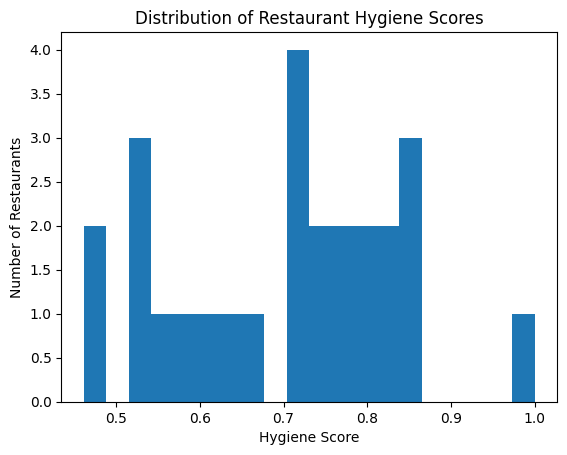

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(restaurant_scores['hygiene_score'], bins=20)
plt.xlabel("Hygiene Score")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Restaurant Hygiene Scores")
plt.show()


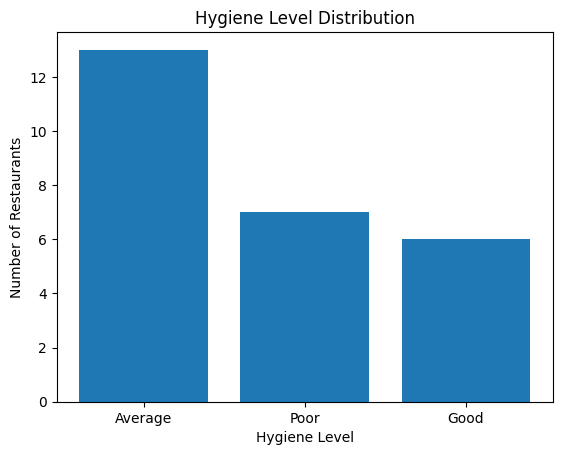

In [23]:
label_counts = restaurant_scores['hygiene_label'].value_counts()

plt.figure()
plt.bar(label_counts.index, label_counts.values)
plt.xlabel("Hygiene Level")
plt.ylabel("Number of Restaurants")
plt.title("Hygiene Level Distribution")
plt.show()


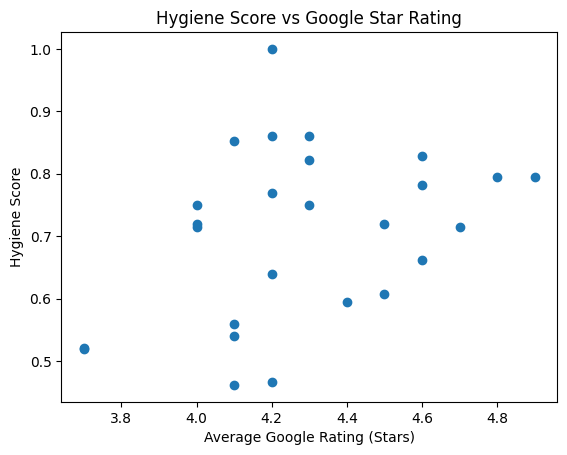

In [24]:
# Average stars per restaurant
avg_stars = (
    final_df
    .groupby('title')['totalScore']
    .mean()
    .reset_index()
)

# Merge with hygiene scores
evaluation_df = restaurant_scores.merge(avg_stars, on='title')

plt.figure()
plt.scatter(evaluation_df['totalScore'], evaluation_df['hygiene_score'])
plt.xlabel("Average Google Rating (Stars)")
plt.ylabel("Hygiene Score")
plt.title("Hygiene Score vs Google Star Rating")
plt.show()

In [25]:
correlation = evaluation_df['hygiene_score'].corr(evaluation_df['totalScore'])
print("Correlation between hygiene score and stars:", correlation)


Correlation between hygiene score and stars: 0.36376632621936195


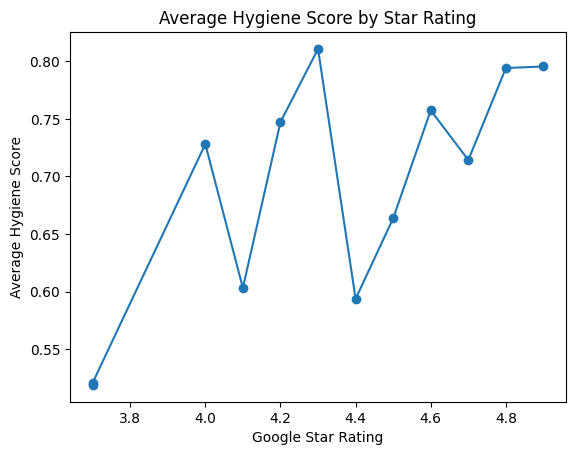

In [26]:
star_groups = evaluation_df.groupby(evaluation_df['totalScore'])['hygiene_score'].mean()

plt.figure()
plt.plot(star_groups.index, star_groups.values, marker='o')
plt.xlabel("Google Star Rating")
plt.ylabel("Average Hygiene Score")
plt.title("Average Hygiene Score by Star Rating")
plt.show()

In [27]:
plt.figure()
plt.scatter(powerbi_restaurants['review_count'], powerbi_restaurants['hygiene_score'])
plt.xlabel("Number of Hygiene Reviews")
plt.ylabel("Hygiene Score")
plt.title("Hygiene Score vs Number of Reviews")
plt.show()

NameError: name 'powerbi_restaurants' is not defined

<Figure size 640x480 with 0 Axes>

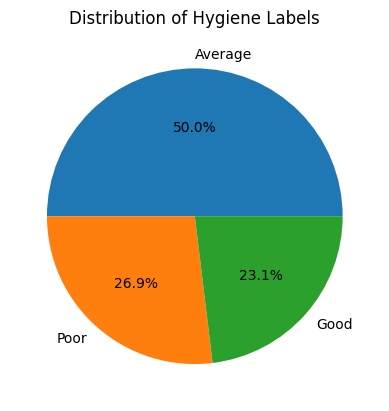

In [ ]:
label_counts = restaurant_scores['hygiene_label'].value_counts()

plt.figure()
plt.pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%')
plt.title("Distribution of Hygiene Labels")
plt.show()

In [ ]:
evaluation_df['rounded_stars'] = evaluation_df['totalScore']

evaluation_df.boxplot(column='hygiene_score', by='rounded_stars')
plt.xlabel("Rounded Star Rating")
plt.ylabel("Hygiene Score")
plt.title("Box Plot of Hygiene Score by Rounded Star Rating")
plt.suptitle("")  
plt.show()

NameError: name 'evaluation_df' is not defined

In [ ]:
evaluation_df['difference'] = evaluation_df['hygiene_score'] - (evaluation_df['totalScore'] / 5)

evaluation_df.sort_values('difference')

,title,hygiene_score,hygiene_label,totalScore,rounded_stars,difference
3,Chicken Delight,0.466667,Poor,4.2,4.2,-0.373333
9,Dallas Chicken & Biscuits,0.461538,Poor,4.1,4.1,-0.358462
2,Charles Pan-Fried Chicken,0.607843,Average,4.5,4.5,-0.292157
18,New York Fried Chicken,0.593750,Poor,4.4,4.4,-0.286250
12,H & Chicken,0.540230,Poor,4.1,4.1,-0.279770
1,Blue Ribbon Fried Chicken,0.558442,Poor,4.1,4.1,-0.261558
4,Chicken Insider,0.661290,Average,4.6,4.6,-0.258710
22,Rokstar Chicken Harlem,0.714286,Average,4.7,4.7,-0.225714
6,Church's Texas Chicken,0.519111,Poor,3.7,3.7,-0.220889
8,Crown Fried Chicken & Pizza,0.520833,Poor,3.7,3.7,-0.219167


In [ ]:
# Review count per restaurant
review_count = (
    final_df
    .groupby('title')
    .size()
    .reset_index(name='review_count')
)

# Average stars
avg_stars = (
    final_df
    .groupby('title')['totalScore']
    .mean()
    .reset_index(name='stars')
)

# Merge everything
powerbi_restaurants = (
    restaurant_scores
    .merge(avg_stars, on='title')
    .merge(review_count, on='title')
)

# Difference metric
powerbi_restaurants['difference'] = (
    powerbi_restaurants['hygiene_score'] - (powerbi_restaurants['stars'] / 5)
)

powerbi_restaurants.head(20)


,title,hygiene_score,hygiene_label,stars,review_count,difference
0,375° Chicken 'n Fries,0.794118,Average,4.8,17,-0.165882
1,Blue Ribbon Fried Chicken,0.558442,Poor,4.1,77,-0.261558
2,Charles Pan-Fried Chicken,0.607843,Average,4.5,51,-0.292157
3,Chicken Delight,0.466667,Poor,4.2,15,-0.373333
4,Chicken Insider,0.661290,Average,4.6,31,-0.258710
5,Chirping Chicken,0.860656,Good,4.3,61,0.000656
6,Church's Texas Chicken,0.519111,Poor,3.7,75,-0.220889
7,Crown Fried Chicken,0.860000,Good,4.2,25,0.020000
8,Crown Fried Chicken & Pizza,0.520833,Poor,3.7,24,-0.219167
9,Dallas Chicken & Biscuits,0.461538,Poor,4.1,13,-0.358462


In [ ]:
powerbi_reviews = final_df[[
    'title',
    'clean_review',
    'hygiene_sentiment',
    'totalScore'
]].copy()

powerbi_reviews.head()


,title,clean_review,hygiene_sentiment,totalScore
0,US Fried Chicken,paid for a sandwich at the deli not only did i...,0.0,4.3
1,US Fried Chicken,always fresh the service is nice,1.0,4.3
2,US Fried Chicken,their frye chicken is always fresh and the piz...,1.0,4.3
3,US Fried Chicken,a really clean spot eat at the workers are rea...,1.0,4.3
4,US Fried Chicken,call in your order and its done when you get t...,1.0,4.3


In [ ]:
kpi_data = pd.DataFrame({
    'metric': [
        'Total Restaurants',
        'Total Hygiene Reviews',
        'Poor Hygiene Restaurants',
        'Good Hygiene Restaurants'
    ],
    'value': [
        powerbi_restaurants.shape[0],
        final_df.shape[0],
        (powerbi_restaurants['hygiene_label'] == 'Poor').sum(),
        (powerbi_restaurants['hygiene_label'] == 'Good').sum()
    ]
})

kpi_data


,metric,value
0,Total Restaurants,26
1,Total Hygiene Reviews,860
2,Poor Hygiene Restaurants,7
3,Good Hygiene Restaurants,6


In [ ]:
powerbi_restaurants.to_csv("powerbi_restaurant_hygiene.csv", index=False)
powerbi_reviews.to_csv("powerbi_review_details.csv", index=False)
kpi_data.to_csv("powerbi_kpis.csv", index=False)
